In [9]:
from sbcbinaryformat import Streamer, Writer
import numpy as np
import matplotlib.pyplot as plt

from GetEvent import GetEvent
from GetEvent import GetScint

from scipy import signal

import csv
import pandas as pd

import os

from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression

import tempfile
import tarfile

import time

from collections import Counter, defaultdict

from scipy.signal import firwin, filtfilt
from scipy.optimize import least_squares
import importlib

In [10]:
def _unwrap_caen_timestamp(ts, max_ts=2**31):
    ts = np.asarray(ts, dtype=np.int64)

    # Detect rollovers
    rollovers = np.diff(ts, axis=-1, prepend=0) < 0

    # Cumulative count of rollovers
    rollover_count = np.cumsum(rollovers, axis=-1)
    return ts + rollover_count * max_ts


def find_offset_correlation(t1_original, t2_original, bin_width=0.00001):
    t1 = np.asarray(t1_original).copy()
    t2 = np.asarray(t2_original).copy()
    t1_0 = t1[0]
    t2_0 = t2[0]
    t1 -= t1_0
    t2 -= t2_0
    
    t_min = min(t1[0], t2[0])
    t_max = max(t1[-1], t2[-1])
    bins = np.arange(t_min, t_max, bin_width)
    hist1, _ = np.histogram(t1, bins=bins)
    hist2, _ = np.histogram(t2, bins=bins)
    
    correlation = signal.correlate(hist1, hist2, mode='full')
    lag = signal.correlation_lags(len(hist1), len(hist2), mode='full')
    lag = lag*bin_width + t1_0 - t2_0
    
    best_lag = lag[np.argmax(correlation)]
    
    return best_lag, correlation, lag

In [11]:
def scint_t0(data):
    results = {}

    results['latch_time_corrected'] = np.nan 
    results['pT0_in_scint_time'] = np.nan 
    results['biggest_pulse_pt0_20ms'] = np.nan 
    results['idx_biggest_pulse_pt0_20ms'] = np.nan 
    results['scint_time_biggest_pulse_pt0_20ms'] = np.nan 
    results['biggest_pulse_random_20ms'] = np.nan 
    results['idx_biggest_pulse_random_20ms'] = np.nan 
    results['scint_time_biggest_pulse_random_20ms'] = np.nan 
    results['biggest_pulse_pt0_40ms'] = np.nan 
    results['idx_biggest_pulse_pt0_40ms'] = np.nan 
    results['scint_time_biggest_pulse_pt0_40ms'] = np.nan 
    results['biggest_pulse_random_40ms'] = np.nan 
    results['idx_biggest_pulse_random_40ms'] = np.nan 
    results['scint_time_biggest_pulse_random_40ms'] = np.nan 
    results['Failed'] = False
    
    ### Digiscope
    digi_data = data['digiscope']
    #print(digi_data)
    
    di_array = digi_data['DI']
    first_num = digi_data['DI'][:,0]

    bit0 = ((first_num >> 0) & 1).astype(bool)

    rising_edges = np.where((~bit0[:-1]) & (bit0[1:]))[0] + 1

    if len(rising_edges) == 0:
        #print('No digi latch')
        #return np.nan
        results['Failed'] = 'No digiscope latch found'
        return results
        
    latch_idx = rising_edges[-1]
    #print(rising_edges)
    #print(latch_idx)
    bit1 = ((first_num >> 1) & 1).astype(bool)
    bit2 = ((first_num >> 2) & 1).astype(bool)

    caen_trig_idx = np.where(bit2)[0]
    if len(caen_trig_idx) == 0:
        #print('NO DIGI TRIGGER')
        #return np.nan
        results['Failed'] = 'No digiscope triggers found'
        return results
        
    #print(caen_trig_idx)
    #print(len(caen_trig_idx))

    #plt.plot(bit0)
    #plt.title('Digiscope Latch')
    #plt.show()

    #plt.plot(bit1)
    #plt.show()

    #plt.scatter(np.arange(0,len(bit2),1),bit2)
    #plt.title('Digiscope CAEN Trig')
    #plt.show()


    unwrapped_timestamps_digi1 = _unwrap_caen_timestamp(digi_data['t_ticks'])
    unwrapped_timestamps_digi = _unwrap_caen_timestamp(unwrapped_timestamps_digi1)
    #plt.plot(unwrapped_timestamps_digi)
    #plt.plot(digi_data['t_ticks'])
    #plt.title('Unwrapped Digi')
    #plt.show()

    latch_timestamp = unwrapped_timestamps_digi[latch_idx]
    latch_time = latch_timestamp / 40e6
    #print(latch_time)
    #print(caen_trig_idx)
    first_caen_timestamp = unwrapped_timestamps_digi[caen_trig_idx[0]]
    last_caen_timestamp = unwrapped_timestamps_digi[caen_trig_idx[-1]]

    latch_minus_first_caen = latch_timestamp-first_caen_timestamp
    latch_time_after_first_caen = latch_minus_first_caen / 40e6
    last_caen_minus_latch_s = (last_caen_timestamp-latch_timestamp) / 40e6
    #print(f'First CAEN trig is {latch_time_after_first_caen} s before latch')
    #print(f'Last CAEN trig is {last_caen_minus_latch_s} s after latch')

    caen_livetime = (last_caen_timestamp - first_caen_timestamp) / 40e6




    timestamps_digi = unwrapped_timestamps_digi[caen_trig_idx]
    digi_tsec = (timestamps_digi / 40e6)

    #plt.plot(digi_tsec)
    #plt.title('Unwrapped digi - CAEN trig index only')
    #plt.show()




    ### Scintillation
    
    scint_data = data['scintillation']
    #print(scint_data)
    #print(Sdata)
    #print('END SDATA')
    #scint_data = Sdata['scintillation']
    #print(scint_data['TriggerTimeTag'])
    #print(scint_data)
    #print('END SCINT_DATA')
    #print(scint_data)
    #scinct_data = scint_data.to_dict()
    
    #print(scint_data['TriggerTimeTag'])
    #plt.plot(scint_data['TriggerTimeTag'])
    #plt.show()
    
    sample_rate =  125e6
    
    TriggerTimeTag = _unwrap_caen_timestamp(scint_data['TriggerTimeTag'])
    #plt.plot(TriggerTimeTag)
    #plt.show()
    if len(TriggerTimeTag) == 0:
        #print('No scint trigger times')
        #return np.nan
        results['Failed'] = 'No scintillation triggers found'
        return results
        
    scint_livetime = (TriggerTimeTag[-1]-TriggerTimeTag[0]) / sample_rate
    scint_tsec = ((TriggerTimeTag-TriggerTimeTag[0]) / sample_rate)
    #print(TriggerTimeTag)
    #print(scint_tsec)
    #plt.plot(TriggerTimeTag)
    #plt.title('Unwrapped Scint Trigger Times')
    #plt.show()

    #print('Scint livetime:',scint_livetime)
    #print('Scint last time minus first time:',(TriggerTimeTag[-1]-TriggerTimeTag[0]) / 125e6,'sec')

    #digi_diff = np.diff(digi_tsec)
    #scint_diff = np.diff(scint_tsec)


    #plt.plot(digi_diff)
    #plt.plot(scint_diff)
    #plt.show()


    #plt.scatter(digi_tsec,np.linspace(0,0,len(digi_tsec)),s=2,label='Digi')
    #plt.scatter(scint_tsec,np.linspace(1,1,len(scint_tsec)),s=2,label='Scint')
    #plt.legend()
    #plt.xlabel('Time [s]')
    #plt.show()






    ### Digi/Scint Correlation
    t, corr, lag = find_offset_correlation(digi_tsec, scint_tsec, bin_width=0.001) # Initial rough correlation, before clock drift fix

    digi_aligned = np.array(digi_tsec) - t
    scint = np.array(scint_tsec)
    #print('len(digi_aligned):',len(digi_aligned))

    #plt.scatter(digi_aligned,np.linspace(0,0,len(digi_tsec)),s=2,label='Digi')
    #plt.scatter(scint,np.linspace(1,1,len(scint_tsec)),s=2,label='Scint')
    #plt.legend()
    #plt.xlabel('Time [s]')
    #plt.show()

    
    # Nearest neighbor, residuals
    
    digi_aligned.sort()
    scint.sort()

    idx = np.searchsorted(scint, digi_aligned)

    idx_left = np.clip(idx - 1, 0, len(scint) - 1)
    idx_right = np.clip(idx, 0, len(scint) - 1)

    diff_left = digi_aligned - scint[idx_left]
    diff_right = digi_aligned - scint[idx_right]

    choose_left = np.abs(diff_left) < np.abs(diff_right)
    residuals = np.where(choose_left, diff_left, diff_right)

    worst_idx = np.argmax(np.abs(residuals))
    worst_residual = residuals[worst_idx]

    threshold = 0.002  # seconds
    residuals_filtered = residuals[np.abs(residuals) < threshold]

    #print("Total digi points:", len(residuals))
    #print("Points within 2 ms:", len(residuals_filtered))

    #print("Worst residual (ms):", worst_residual * 1000)
    #print("Corresponding digi time (aligned s):", digi_aligned[worst_idx])

    '''
    plt.figure()
    plt.hist(residuals * 1000, bins=50)
    plt.xlabel("Timing offset at best correlation [ms]")
    plt.ylabel("Counts")
    plt.show()

    plt.figure()
    plt.hist(residuals_filtered * 1000, bins=50)
    plt.xlabel("Timing offset at best correlation [ms]")
    plt.ylabel("Counts")
    plt.show()

    plt.figure()
    plt.scatter(digi_aligned, residuals * 1000, s=5)
    #plt.axhline(0, color = 'red', linestyle = '--')
    plt.xlabel("Digi time [s]")
    plt.ylabel("Timing offset to nearest scint [ms]")
    plt.title("Timing Offset vs Time")
    plt.show()
    '''


    threshold = 0.002  # seconds
    #threshold = 0.02  # seconds

    mask = np.abs(residuals) <= threshold

    digi_aligned_filtered = digi_aligned[mask]
    residuals_filtered = residuals[mask]

    #print("Removed points:", np.sum(~mask))
    #print("Remaining points:", np.sum(mask))

    '''
    plt.figure()
    plt.scatter(digi_aligned_filtered, residuals_filtered * 1000, s=5)
    #plt.axhline(0, color = 'red', linestyle = '--')
    plt.xlabel("Digi time [s]")
    plt.ylabel("Timing offset to nearest scint [ms]")
    plt.title("Timing Offset vs Time")
    plt.show()
    '''

    # Fit clock drift
    X = digi_aligned_filtered.reshape(-1, 1)
    y = residuals_filtered
    if len(X) < 2:
        #print('Not enough points to fit')
        #return np.nan
        results['Failed'] = 'Not enough points for RANSAC'
        return results
        
    ransac = RANSACRegressor(LinearRegression(),
                             residual_threshold=0.0000005)  # 0.5us
                             #residual_threshold=0.000005)
    ransac.fit(X, y)

    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask

    m = ransac.estimator_.coef_[0]
    b = ransac.estimator_.intercept_

    #print("Slope (clock drift):", m) 
    #print("Intercept:", b)
    #print("Inliers:", np.sum(inlier_mask))
    #print("Outliers:", np.sum(outlier_mask))

    #print('len(digi_aligned_filtered):',len(digi_aligned_filtered))
    #print(digi_aligned_filtered)
    '''
    plt.figure()

    plt.scatter(digi_aligned_filtered[inlier_mask],
                residuals_filtered[inlier_mask]*1000,
                s=5, label="Inliers")

    plt.scatter(digi_aligned_filtered[outlier_mask],
                residuals_filtered[outlier_mask]*1000,
                s=5, label="Outliers")

    xline = np.linspace(digi_aligned_filtered.min(), digi_aligned_filtered.max(), 1000)
    plt.plot(xline, (m*xline + b)*1000, linewidth=2, label="RANSAC fit")

    plt.xlabel("Digi time (post initial correlation) [s]")
    plt.ylabel("Timing offset [ms]")
    plt.legend()
    plt.show()
    '''

    x_in = digi_aligned_filtered[inlier_mask]
    y_in = residuals_filtered[inlier_mask]

    resid_to_fit = y_in - (m * x_in + b)

    resid_us = resid_to_fit * 1e6

    #print("Average (us):", np.mean(resid_us))
    #print("Std dev (us):", np.std(resid_us))
    #print("Maximum |variation| (us):", np.max(np.abs(resid_us)))


    # Recheck nearest neighbor, residuals

    digi_inliers = digi_aligned_filtered[inlier_mask]
    residuals_inliers = residuals_filtered[inlier_mask]

    digi_corrected = (1 - m) * digi_inliers - b

    idx = np.searchsorted(scint, digi_corrected)

    idx_left = np.clip(idx - 1, 0, len(scint) - 1)
    idx_right = np.clip(idx, 0, len(scint) - 1)

    diff_left = digi_corrected - scint[idx_left]
    diff_right = digi_corrected - scint[idx_right]

    choose_left = np.abs(diff_left) < np.abs(diff_right)
    residuals_final = np.where(choose_left, diff_left, diff_right)

    
    #plt.scatter(digi_corrected,residuals_final * 1e6, label='Digi corrected')
    #plt.ylabel('Offset [us]')
    #plt.xlabel('Digi time (corrected) [s]')
    #plt.legend()
    #plt.show()

    '''
    ############ Test
    digi_corrected2 = (1 - m) * digi_aligned - b

    idx2 = np.searchsorted(scint, digi_corrected2)

    idx_left2 = np.clip(idx2 - 1, 0, len(scint) - 1)
    idx_right2 = np.clip(idx2, 0, len(scint) - 1)

    diff_left2 = digi_corrected2 - scint[idx_left2]
    diff_right2 = digi_corrected2 - scint[idx_right2]

    choose_left2 = np.abs(diff_left2) < np.abs(diff_right2)
    residuals_final2 = np.where(choose_left2, diff_left2, diff_right2)

    
    plt.scatter(digi_corrected2,residuals_final2 * 1e6, label='Digi corrected2')
    plt.ylabel('Offset [us]')
    plt.xlabel('Digi time (corrected) [s]')
    plt.xlim(15,90)
    plt.ylim(-10,10)
    #plt.legend()
    plt.show()

    plt.hist(residuals_final2 * 1e6)
    plt.ylabel('Count')
    plt.xlabel('Offset [us]')
    #plt.legend()
    plt.show()
    ####################
    '''

    #plt.hist(residuals_final * 1e6)
    #plt.ylabel('Count')
    #plt.xlabel('Offset [us]')
    #plt.legend()
    #plt.show()
    
    #print("Final mean residual (us):", np.mean(residuals_final) * 1e6)
    #print("Final std residual (us):", np.std(residuals_final) * 1e6)
    #print("Final max |residual| (us):", np.max(np.abs(residuals_final)) * 1e6)


    '''
    plt.vlines(digi_corrected, ymin=0.5, ymax=1.5,color='blue', label="digiscope")
    plt.vlines(scint_tsec, ymin=1.5, ymax=2.5,color='orange', label="caen")
    plt.xlabel("time (s)")
    plt.ylabel("caen trigger")
    plt.legend()
    #plt.xlim(0.15, 0.25)
    #plt.xlim(39, 40.75)
    #plt.xlim(23, 24)
    plt.ylim(-3, 5)
    plt.show()
    '''


    '''
    t, corr, lag = find_offset_correlation(digi_corrected, scint_tsec, bin_width=0.00001)
    print(f"t: {t}")



    plt.plot(lag, corr)
    plt.xlabel("lag (s)")
    plt.ylabel("correlation")
    plt.show()
    '''


    latch_time_corrected = ((1 - m) * (latch_time-t) - b) * 1000 # ms
    #print('Latch time corrected:',latch_time_corrected)

    results['latch_time_corrected'] = latch_time_corrected

    
    
    ### PressureT0
    pressureT0_file = f'/exp/e961/data/SBC-25-recon/dev-output/{data['event_info']['run_id'][0]}/pressure_t0.sbc'
    #pressureT0_file = f'/exp/e961/data/SBC-25-recon/dev-output/20260212_1/pressure_t0.sbc'
    
    #print(pressureT0_file)
    if os.path.isfile(pressureT0_file):
        pressureT0_results = Streamer(pressureT0_file)
        pressureT0_results = pressureT0_results.to_dict()

        current_ev_idx = np.where(pressureT0_results['ev'] == data['event_info']['event_id'])[0][0]
        pressureT0 = pressureT0_results['t0_fitting'][current_ev_idx]  # ms
        if pressureT0 == 0:
            #print('pT0 failed')
            #return np.nan
            results['Failed'] = 'pT0 = 0'
            return results
            
        pt0_rel_to_trig = -1*((data['run_control']['acous']['pre_trig_len'] * 1000) - pressureT0)
        #print('PressureT0 relative to trigger (negative is before):',pt0_rel_to_trig)
    
    else:
        #print('No pt0 file')
        #return np.nan
        results['Failed'] = 'No pT0 found'
        return results

    pressureT0_in_corrected_time = latch_time_corrected + pt0_rel_to_trig # ms
    #print('PressureT0 in corrected time:',pressureT0_in_corrected_time)
    results['pT0_in_scint_time'] = pressureT0_in_corrected_time


    '''
    plt.vlines(digi_corrected, ymin=0.5, ymax=1.5,color='blue', label="digiscope")
    plt.vlines(scint_tsec, ymin=1.5, ymax=2.5,color='orange', label="caen")
    plt.vlines(pressureT0_in_corrected_time / 1000, ymin=-5, ymax=5, linestyle = '--', color='r', label='pt0')
    plt.xlabel("time (s)")
    plt.ylabel("caen trigger")
    plt.legend()
    #plt.xlim(0.15, 0.25)
    #plt.xlim(39, 40.75)
    plt.xlim((pressureT0_in_corrected_time / 1000)-0.05, (pressureT0_in_corrected_time / 1000)+0.05)
    plt.ylim(-3, 5)
    plt.show()
    '''

    #print(len(scint_tsec))
    #print(len(data['scintillation']['Waveforms']))


    scintillation_hits_file = f'/exp/e961/data/SBC-25-recon/dev-output/{data['event_info']['run_id'][0]}/scintillation.sbc'
    #scintillation_hits_file = f'/exp/e961/data/SBC-25-recon/dev-output/20260212_1/scintillation.sbc'
    
    if os.path.isfile(scintillation_hits_file):
        scintillation_hits = Streamer(scintillation_hits_file)
        scintillation_hits = scintillation_hits.to_dict()
        #print(scintillation_hits)
        #print(scintillation_hits['wvf_area'])
        #print(scintillation_hits['hit_t0'])
    
        mask_ev = scintillation_hits['ev'] == data['event_info']['event_id']
        
        ev = {
            k: np.asarray(v)[mask_ev]
            for k, v in scintillation_hits.items()
        }
        #print(ev)
    
    else:
        #print('No scintillation.sbc file')
        #return np.nan
        results['Failed'] = 'No scintillation hits found'
        return results


    hit_area = ev['hit_area']

    hit_area_arr = np.array(hit_area, dtype=float)
    #print(hit_area_arr)

    hit_sums = np.nansum(hit_area_arr, axis=1)
    '''
    plt.axhline(0)  # horizontal baseline at y=0

    plt.vlines(
        scint_tsec,      
        0,               
        hit_sums         
    )
    plt.axvline(pressureT0_in_corrected_time / 1000, linestyle = '--', color='r')
    plt.xlim((pressureT0_in_corrected_time / 1000) - 0.5, (pressureT0_in_corrected_time / 1000) +0.5)
    plt.ylim(-0.1e6,0.8e6)
    plt.show()


    plt.axhline(0)  

    plt.vlines(
        scint_tsec,      
        0,               
        hit_sums         
    )
    #plt.axvline(pressureT0_in_corrected_time / 1000, linestyle = '--')
    plt.xlim((pressureT0_in_corrected_time / 1000) - 0.5, (pressureT0_in_corrected_time / 1000) +0.5)
    plt.ylim(-0.1e6,0.8e6)
    plt.show()
    #print(hit_sums)
    #print(len(hit_sums))
    '''
    results['hit_sums'] = hit_sums
    results['scint_tsec'] = scint_tsec



    # Biggest pulse 20ms near pT0

    pt0_window = 0.020  # seconds
    
    window_mask = np.abs(scint_tsec - (pressureT0_in_corrected_time/1000)) <= pt0_window
    
    window_indices = np.where(window_mask)[0]
    #print('Number of pulses within 20ms:',len(window_indices))
    
    if len(window_indices) == 0:
        biggest_pulse_within_20ms_pt0 = np.nan
        index_biggest_pulse_within_20ms_pt0 = np.nan
        scint_time_biggest_pulse_within_20ms_pt0 = np.nan
    else:
        window_values = hit_sums[window_indices]
    
        local_max_idx = np.nanargmax(window_values)
        index_biggest_pulse_within_20ms_pt0 = window_indices[local_max_idx]
    
        biggest_pulse_within_20ms_pt0 = window_values[local_max_idx]

        scint_time_biggest_pulse_within_20ms_pt0 = scint_tsec[index_biggest_pulse_within_20ms_pt0]
    
    #print('Biggest pulse within 20ms of pt0:',biggest_pulse_within_20ms_pt0)
    #print('Index:',index_biggest_pulse_within_20ms_pt0)
    #print('Scint time:',scint_time_biggest_pulse_within_20ms_pt0)

    results['biggest_pulse_pt0_20ms'] = biggest_pulse_within_20ms_pt0
    results['idx_biggest_pulse_pt0_20ms'] = index_biggest_pulse_within_20ms_pt0
    results['scint_time_biggest_pulse_pt0_20ms'] = scint_time_biggest_pulse_within_20ms_pt0 * 1000





    # Biggest pulse within random +-20ms window (excluding pT0 window)

    pt0_center = pressureT0_in_corrected_time / 1000
    
    # Random window only before pT0 - 20ms
    random_center_min = pt0_window
    random_center_max = pt0_center - (2* pt0_window)
    
    biggest_pulse_random_20ms = np.nan
    index_biggest_pulse_random_20ms = np.nan
    scint_time_biggest_pulse_random_20ms = np.nan
    
    if random_center_max > random_center_min: # failed pT0 gives pT0 = 0
    
        random_center = np.random.uniform(random_center_min,random_center_max)
        random_window_mask = np.abs(scint_tsec - random_center) <= pt0_window
        random_window_indices = np.where(random_window_mask)[0]
    
        #print('Random window center:', random_center)
        #print('Number of pulses within random 40ms window:',len(random_window_indices))
    
        if len(random_window_indices) > 0:
    
            random_window_values = hit_sums[random_window_indices]
    
            local_max_idx = np.nanargmax(random_window_values)
            index_biggest_pulse_random_20ms = random_window_indices[local_max_idx]
    
            biggest_pulse_random_20ms = random_window_values[local_max_idx]
    
            scint_time_biggest_pulse_random_20ms = scint_tsec[index_biggest_pulse_random_20ms]
    
    #print('Biggest pulse within random 40ms window:',biggest_pulse_random_20ms)
    #print('Index:',index_biggest_pulse_random_20ms)
    #print('Scint time:',scint_time_biggest_pulse_random_20ms)
    
    results['biggest_pulse_random_20ms'] = biggest_pulse_random_20ms
    results['idx_biggest_pulse_random_20ms'] = index_biggest_pulse_random_20ms
    results['scint_time_biggest_pulse_random_20ms'] = scint_time_biggest_pulse_random_20ms * 1000





    # Biggest pulse 40ms near pT0

    pt0_window = 0.040  # seconds
    
    window_mask = np.abs(scint_tsec - (pressureT0_in_corrected_time/1000)) <= pt0_window
    
    window_indices = np.where(window_mask)[0]
    #print('Number of pulses within 20ms:',len(window_indices))
    
    if len(window_indices) == 0:
        biggest_pulse_within_40ms_pt0 = np.nan
        index_biggest_pulse_within_40ms_pt0 = np.nan
        scint_time_biggest_pulse_within_40ms_pt0 = np.nan
    else:
        window_values = hit_sums[window_indices]
    
        local_max_idx = np.nanargmax(window_values)
        index_biggest_pulse_within_40ms_pt0 = window_indices[local_max_idx]
    
        biggest_pulse_within_40ms_pt0 = window_values[local_max_idx]

        scint_time_biggest_pulse_within_40ms_pt0 = scint_tsec[index_biggest_pulse_within_40ms_pt0]
    
    #print('Biggest pulse within 20ms of pt0:',biggest_pulse_within_20ms_pt0)
    #print('Index:',index_biggest_pulse_within_20ms_pt0)
    #print('Scint time:',scint_time_biggest_pulse_within_20ms_pt0)

    results['biggest_pulse_pt0_40ms'] = biggest_pulse_within_40ms_pt0
    results['idx_biggest_pulse_pt0_40ms'] = index_biggest_pulse_within_40ms_pt0
    results['scint_time_biggest_pulse_pt0_40ms'] = scint_time_biggest_pulse_within_40ms_pt0 * 1000





    # Biggest pulse within random +-40ms window (excluding pT0 window)

    pt0_center = pressureT0_in_corrected_time / 1000
    
    # Random window only before pT0 - 20ms
    random_center_min = pt0_window
    random_center_max = pt0_center - (2* pt0_window)
    
    biggest_pulse_random_40ms = np.nan
    index_biggest_pulse_random_40ms = np.nan
    scint_time_biggest_pulse_random_40ms = np.nan
    
    if random_center_max > random_center_min: # failed pT0 gives pT0 = 0
    
        random_center = np.random.uniform(random_center_min,random_center_max)
        random_window_mask = np.abs(scint_tsec - random_center) <= pt0_window
        random_window_indices = np.where(random_window_mask)[0]
    
        #print('Random window center:', random_center)
        #print('Number of pulses within random 40ms window:',len(random_window_indices))
    
        if len(random_window_indices) > 0:
    
            random_window_values = hit_sums[random_window_indices]
    
            local_max_idx = np.nanargmax(random_window_values)
            index_biggest_pulse_random_40ms = random_window_indices[local_max_idx]
    
            biggest_pulse_random_40ms = random_window_values[local_max_idx]
    
            scint_time_biggest_pulse_random_40ms = scint_tsec[index_biggest_pulse_random_40ms]
    
    #print('Biggest pulse within random 40ms window:',biggest_pulse_random_20ms)
    #print('Index:',index_biggest_pulse_random_20ms)
    #print('Scint time:',scint_time_biggest_pulse_random_20ms)
    
    results['biggest_pulse_random_40ms'] = biggest_pulse_random_40ms
    results['idx_biggest_pulse_random_40ms'] = index_biggest_pulse_random_40ms
    results['scint_time_biggest_pulse_random_40ms'] = scint_time_biggest_pulse_random_40ms * 1000
    
    
    
    return results
    

    
    

In [12]:
#runid = '20260209_11'
runid = '20251125_6'
run_folder = f'/exp/e961/data/SBC-25-unpacked/{runid}'
#event = 6
event = 14
data = GetEvent(run_folder, event, strictMode=False, lazy_load_scintillation = False)

results = scint_t0(data)
# 20251125_7, 12, 16
# 20260209_11, 5, 6

/exp/e961/app/users/dpyda/LAr10Ana/GetEvent.py:164: UserWarning: Missing camera file in the run directory. Data will not be available in the returned dictionary.
  warnings.warn("Missing camera file in the run directory. Data will not be available in the returned dictionary.")


In [13]:
pt0_file = f"/exp/e961/data/SBC-25-recon/dev-output/{runid}/acoustic_noise.sbc"
pt0_data = Streamer(pt0_file).to_dict()
#print(pt0_data)
print(pt0_data['succ_expansion'][event])

True


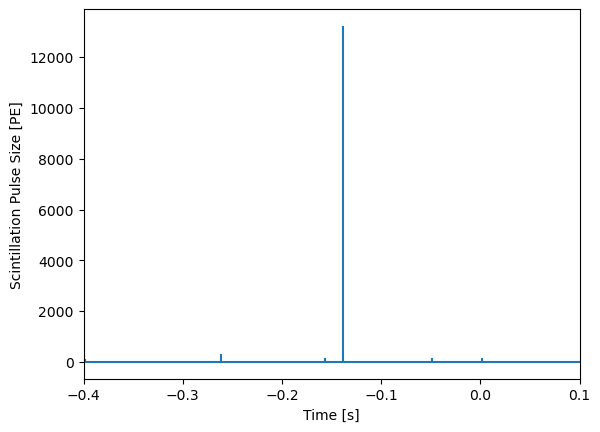

121030.644992


In [14]:
plt.axhline(0)

plt.vlines(
    results['scint_tsec'] - (results['latch_time_corrected']/1000),      
    0,               
    (results['hit_sums']/90)         
)
#plt.axvline((results['pT0_in_scint_time']-results['latch_time_corrected']) / 1000, linestyle = '--', color='r')
#plt.xlim(((results['pT0_in_scint_time']-results['latch_time_corrected']) / 1000) - 0.5, ((results['pT0_in_scint_time']-results['latch_time_corrected']) / 1000) +0.5)
#plt.ylim(-0.1e6,0.8e6)
plt.xlim(-44,5)
plt.xlabel('Time [s]')
plt.ylabel('Scintillation Pulse Size [PE]')
plt.xlim(-0.4,0.1)
plt.show()

print(results['scint_tsec'][1585]*1000)

In [15]:
print(np.where((results['hit_sums']/90)>30000))
pt0_file = f"/exp/e961/data/SBC-25-recon/dev-output/{runid}/exposure.sbc"
pt0_data = Streamer(pt0_file).to_dict()
#print(pt0_data)
print(pt0_data['PT2121_livetime'][event])

(array([], dtype=int64),)
92.83


686.679900875676


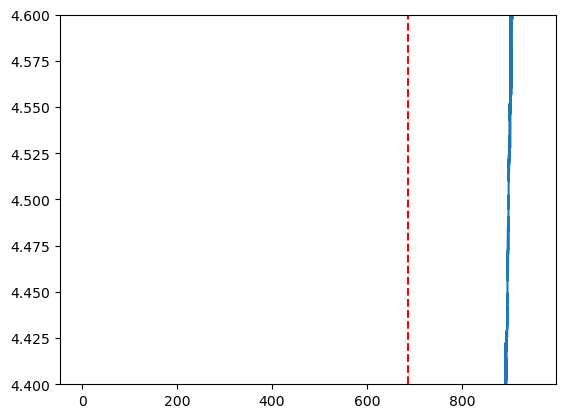

In [16]:
wvfs = data["acoustics"]["Waveforms"]

wvfs_psi = wvfs * (-35 / 2 ** 16)

piezo0 = wvfs_psi[0, 7, :]

xlimit = [0, 800]
ylimit = [-22.5, -20]
ylimit = [-20, -18]
# first check if the expansion success
average_window_expansion = 100


average_window = 50  # every 50 data, do the average
n_chunked = (len(piezo0) // average_window) * average_window  # chunk data
piezo0 = piezo0[:n_chunked]

# time in miliseconds
total_time = len(piezo0)
time_list_ms = [i / 1e3 for i in range(0, total_time, 1)]
time_list_ms = np.array(time_list_ms[:n_chunked])

# max time to be fit
time_max_raw = max(time_list_ms)


piezo0 = piezo0.reshape(-1, average_window).mean(axis=1)
time_list_ms = time_list_ms.reshape(-1, average_window).mean(axis=1)

pt0_file = f"/exp/e961/data/SBC-25-recon/dev-output/{runid}/pressure_t0.sbc"
pt0_data = Streamer(pt0_file).to_dict()
pt0 = pt0_data['t0_fitting'][event]
print(pt0)

plt.axvline(pt0,color='red',linestyle='--')
#plt.xlim(600,800)
plt.ylim(4.4,4.6)
plt.plot(time_list_ms,piezo0)
plt.show()


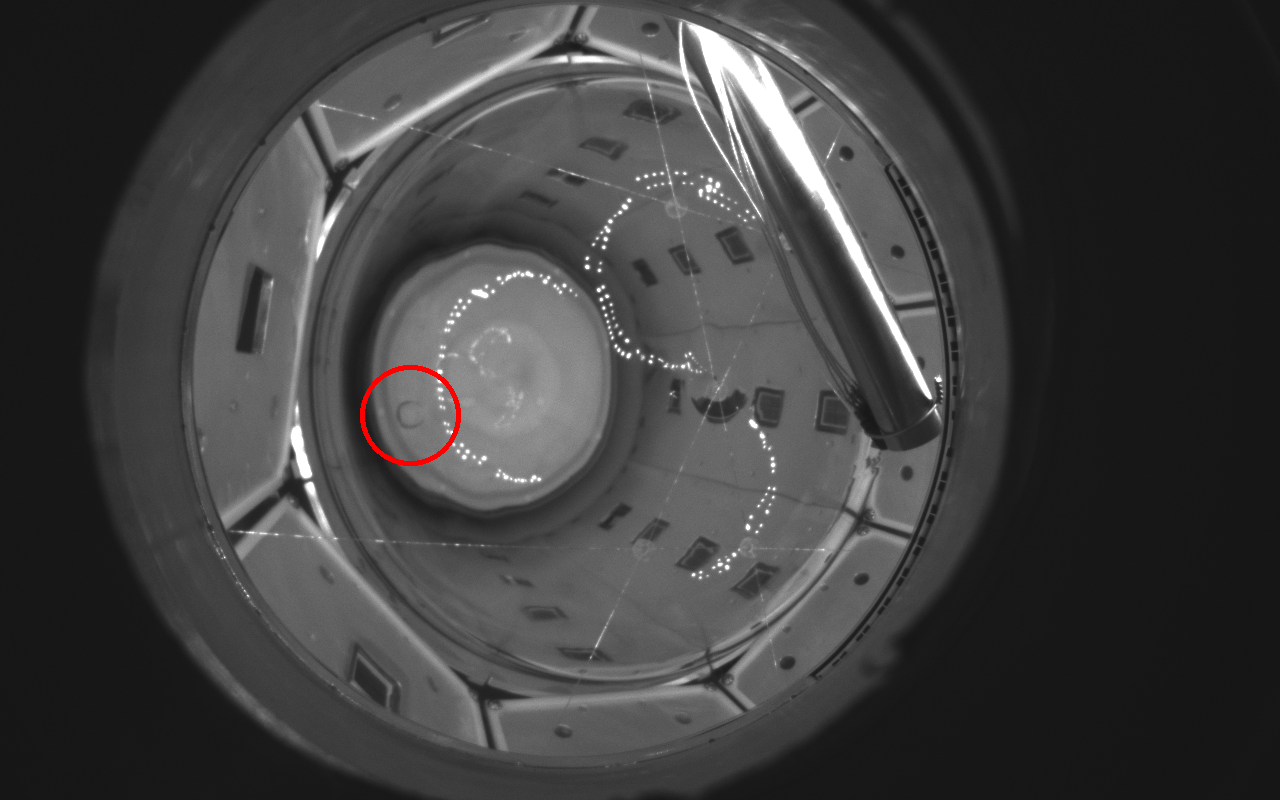

In [17]:
runid = '20260209_11'
event = 6
runid = '20251125_6'
event = 18
img_file = f"/exp/e961/data/SBC-25-unpacked/{runid}/{event}/cam1-img06.png"

from PIL import Image, ImageDraw
from IPython.display import display

img = Image.open(img_file).convert("RGB")

x, y = 410, 415   
r = 50            

draw = ImageDraw.Draw(img)
draw.ellipse(
    (x - r, y - r, x + r, y + r),
    outline="red",
    width=5
)

img.save("Cam3wBub.png")
display(img)

odict_keys(['time_ms', 'valves', 'TT6415', 'PT1101', 'TT2118', 'TT2119', 'PT2121', 'PT3332', 'PT3333', 'CYL3334_FCALC', 'LT3335', 'SERVO3321_OUT', 'SERVO3321_IN'])
[18.592682 18.592682 18.592682 ... 17.265015 17.260742 17.260742]


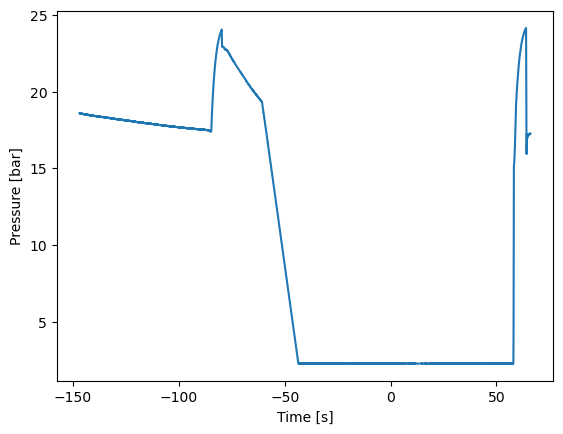

In [18]:
#scint_file = ("/exp/e961/data/SBC-25-recon/dev-output/20260209_11/exposure.sbc")
scint_file = ("/exp/e961/data/SBC-25-unpacked/20251125_6/18/slow_daq.sbc")
scint = Streamer(scint_file).to_dict()

print(scint.keys())
print(scint['PT2121'])

plt.plot((scint['time_ms']/1000)-147,scint['PT2121'])
plt.xlabel('Time [s]',fontsize = 10)
plt.ylabel('Pressure [bar]', fontsize = 10)
plt.show()

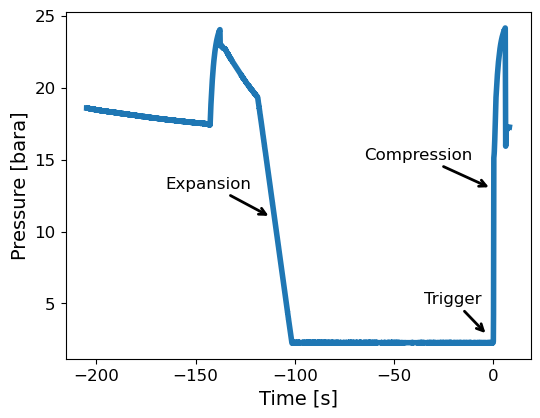

In [19]:
plt.figure(figsize=(6,4.5))

plt.plot((scint['time_ms']/1000)-205, scint['PT2121'],lw=4)

plt.xlabel('Time [s]', fontsize=14)
plt.tick_params(labelsize=12)
plt.ylabel('Pressure [bara]', fontsize=14)


plt.annotate(
    "Expansion",
    xy=(-112, 11),       # arrow tip (x,y)
    xytext=(-165, 13),    # text position
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    fontsize=12
)


plt.annotate(
    "Compression",
    xy=(-1, 13),       # arrow tip (x,y)
    xytext=(-65, 15),    # text position
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    fontsize=12
)



plt.annotate(
    "Trigger",
    xy=(-3, 2.8),       # arrow tip (x,y)
    xytext=(-35, 5),    # text position
    arrowprops=dict(
        arrowstyle="->",
        lw=2
    ),
    fontsize=12
)

plt.savefig("SlowDAQPressure.png")
plt.show()

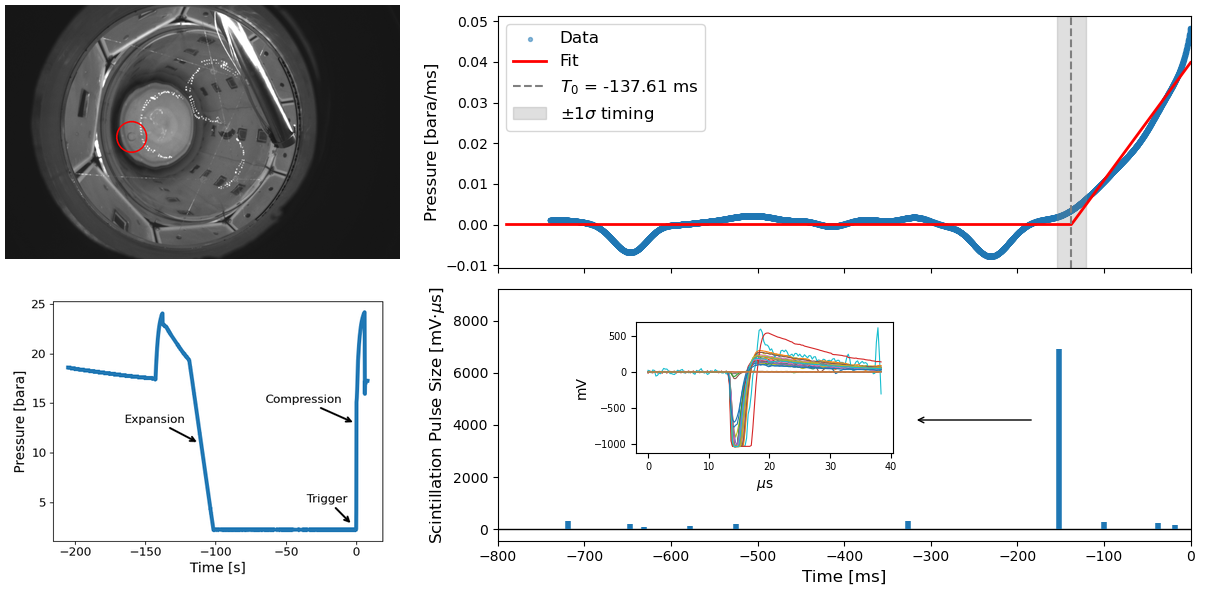

In [26]:
from PIL import Image
from IPython.display import display


cam = Image.open("Cam3wBub.png")
slow = Image.open("SlowDAQPressure.png")
ps = Image.open("PressureScint.png")
reco = Image.open("3DReco.png")

padding = 10

target_height = ps.height


col1_width = 400   


available_height = target_height - padding
cam_height = int(0.6 * available_height)      
slow_height = available_height - cam_height  


cam = cam.resize((col1_width-5, cam_height-100), Image.Resampling.LANCZOS)
slow = slow.resize((col1_width+25, slow_height+75), Image.Resampling.LANCZOS)
reco = reco.resize((col1_width-10, ps.height), Image.Resampling.LANCZOS)


canvas_width = col1_width + padding + ps.width
canvas_height = max(target_height, reco.height)

canvas = Image.new("RGB", (canvas_width, canvas_height), "white")


canvas.paste(cam, (5, 5))
canvas.paste(slow, (0, cam_height + padding-100))
canvas.paste(ps, (col1_width + padding, 0))
#canvas.paste(reco, (col1_width + padding + ps.width + padding, 0))

canvas.save("CombinedEventFigure.png")
display(canvas)

In [20]:
base_dir = "/exp/e961/data/SBC-25-recon/v0.1.2/"

pressureT0 = []
scintT0 = []
big_scint = []

for run in sorted(os.listdir(base_dir)):
    run_path = os.path.join(base_dir, run)

    if not os.path.isdir(run_path):
        continue

    scint_file = os.path.join(run_path, "scint_t0.sbc")

    if not os.path.exists(scint_file):
        continue

    try:
        scint_t0 = Streamer(scint_file).to_dict()
    except Exception as e:
        #print(f"Failed to read {scint_file}: {e}")
        continue

    n_events = len(scint_t0["ev"])

    for i in range(n_events):

        if scint_t0["Failed"][i] != 0:
            continue
        
        pressureT0.append(scint_t0["pT0_in_scint_time"][i])
        scintT0.append(scint_t0["scint_time_biggest_pulse_pt0_40ms"][i])
        big_scint.append(scint_t0["biggest_pulse_pt0_40ms"][i])

pressureT0 = np.asarray(pressureT0)
scintT0 = np.asarray(scintT0)
big_scint = np.asarray(big_scint)

print(f"Saved {len(pressureT0)} good events.")

Saved 1450 good events.


21.231788875181145
2.3621158202732273


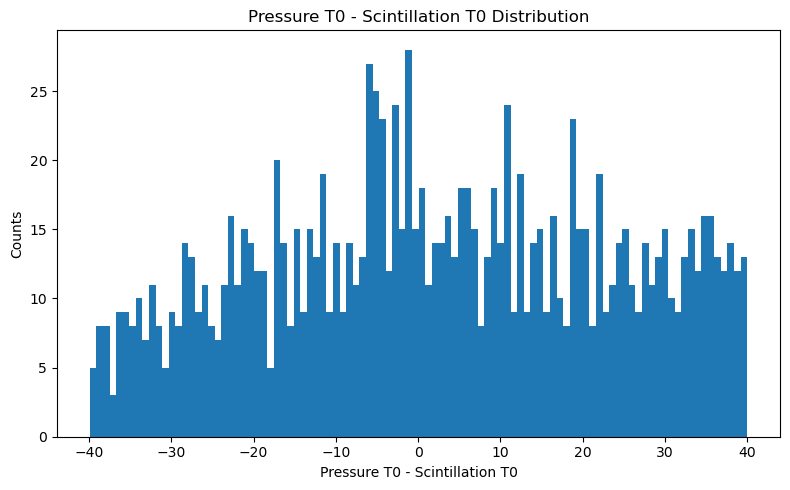

In [21]:
dt = pressureT0 - scintT0
std = np.nanstd(dt)
print(std)
print(np.nanmean(dt))

plt.figure(figsize=(8,5))
plt.hist(dt, bins=100)

plt.xlabel("Pressure T0 - Scintillation T0")
plt.ylabel("Counts")
plt.title("Pressure T0 - Scintillation T0 Distribution")

plt.tight_layout()
plt.show()

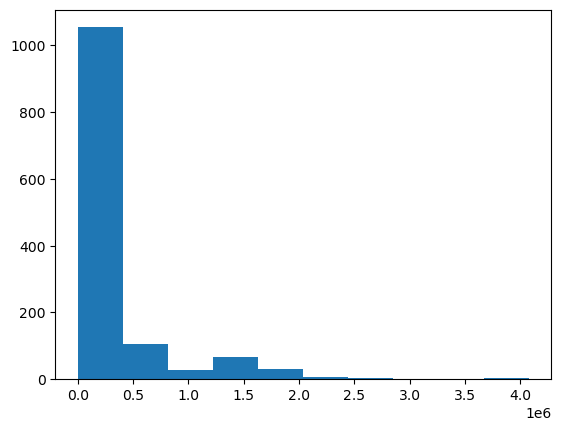

In [22]:
plt.hist(big_scint)
plt.show()

Number of events passing cut: 356


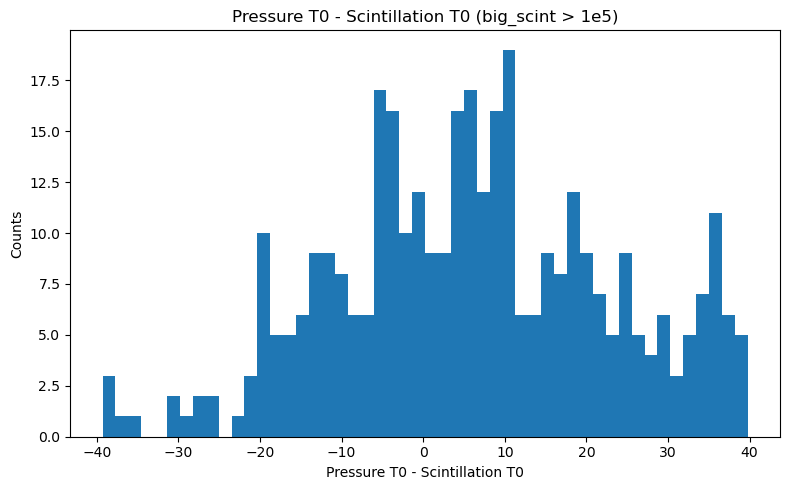

In [23]:
# Select only large events
mask = big_scint > 1e5

dt = pressureT0[mask] - scintT0[mask]

print(f"Number of events passing cut: {len(dt)}")

plt.figure(figsize=(8,5))
plt.hist(dt, bins=50)

plt.xlabel("Pressure T0 - Scintillation T0")
plt.ylabel("Counts")
plt.title("Pressure T0 - Scintillation T0 (big_scint > 1e5)")

plt.tight_layout()
plt.show()

In [25]:
print(f"Std = {np.std(dt)}")
print(f"Mean = {np.mean(dt)}")
print(f"Median = {np.median(dt)}")

Std = 17.049639685142395
Mean = 6.110497212513273
Median = 5.706034278940933
